In [1]:
from model import SVHNNet
import pickle
import numpy as np
import cv2
from utils.extract_patch import ExtractPatch
from utils.mean_subtract import MeanSubtract
from utils.generator import Generator
import os
import tensorflow as tf

from keras.optimizers import Adam
from keras.callbacks import LearningRateScheduler
from keras.callbacks import TensorBoard
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from tensorflow.python.client import device_lib

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

['/device:CPU:0', '/device:GPU:0']


In [3]:
width = 54
height = 54
depth = 3
classes = 11
BS = 128
epochs = 50

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

### Pretrain the model on the extra dataset

In [5]:
means = pickle.load(open("rgb_means.pkl", "rb"))

ep = ExtractPatch(width, height)
ms = MeanSubtract(means["R"], means["G"], means["B"])
preprocessors = [ep, ms]

generator = Generator("hdf5/extra_train.hdf5", BS, epochs, preprocessors)

In [6]:
model = SVHNNet.build(height, width, depth, classes)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 54, 54, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 54, 54, 48)   3648        ['input_1[0][0]']                
                                                                                                  
 activation (Activation)        (None, 54, 54, 48)   0           ['conv2d[0][0]']                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 54, 54, 48)  192         ['activation[0][0]']             
 alization)                                                                                   

In [7]:
# https://towardsdatascience.com/learning-rate-schedules-and-adaptive-learning-rate-methods-for-deep-learning-2c8f433990d1
# exponential decay
def exp_decay(epoch):
    initial_lrate = 0.001
    k = 0.1
    lrate = initial_lrate * np.exp(-k*epoch)
    
    return lrate

In [8]:
opt = Adam(lr=0.001)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
callbacks = [TensorBoard("logs", batch_size=BS, write_images=True),
            LearningRateScheduler(exp_decay)]

C:\Users\mehrdad hooshangi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [9]:
H = model.fit_generator(generator.generate(), steps_per_epoch=generator.n_img//BS, epochs=10, callbacks=callbacks)

C:\Users\mehrdad hooshangi\AppData\Local\Temp\ipykernel_6304\1628828992.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  H = model.fit_generator(generator.generate(), steps_per_epoch=generator.n_img//BS, epochs=10, callbacks=callbacks)


StopIteration: 

In [ ]:
model.save("pretrain.h5")

1/1 [==============================] - 3s 3s/step
[7, 1]


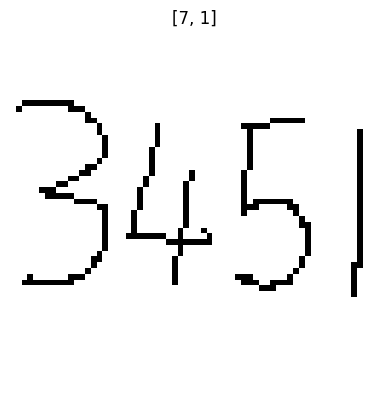

In [10]:
# simply testing it
test_img = cv2.imread("test.png")
ori_test = test_img.copy()
test_img = cv2.resize(test_img, (54, 54))
test_img = ms.preprocess(test_img)
test_img = np.expand_dims(test_img, axis=0)

prediction = model.predict(test_img)

value = []
for pred in prediction:
    value.append(np.argmax(pred))
    
print(value[:value[-1]])

plt.imshow(cv2.cvtColor(ori_test, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(value[:value[-1]])
plt.show()

## Training the model on the training set

In [11]:
# initializa the generators

train_gen = Generator("hdf5/train.hdf5", BS, epochs, preprocessors)
val_gen = Generator("hdf5/val.hdf5", BS, epochs, preprocessors)

# callbacks, add in earlystopping
callbacks = [TensorBoard("logs", batch_size=BS, write_images=True),
            LearningRateScheduler(exp_decay),
            EarlyStopping(monitor="val_loss", min_delta=0.05, patience=20)]

In [19]:
# using back the same model
with tf.device("/gpu:0"):
    H = model.fit_generator(train_gen.generate(), validation_data=val_gen.generate(), steps_per_epoch=train_gen.n_img//BS,
                            validation_steps=val_gen.n_img//BS, epochs=epochs, callbacks=callbacks)

Epoch 1/50


C:\Users\mehrdad hooshangi\AppData\Local\Temp\ipykernel_6304\2585452148.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  H = model.fit_generator(train_gen.generate(), validation_data=val_gen.generate(), steps_per_epoch=train_gen.n_img//BS,


241/241 [==============================] - 20s 79ms/step - loss: 1.1853 - dense_2_loss: 0.3554 - dense_3_loss: 0.3869 - dense_4_loss: 0.2401 - dense_5_loss: 0.0716 - dense_6_loss: 0.0015 - dense_7_loss: 0.1298 - dense_2_accuracy: 0.8919 - dense_3_accuracy: 0.8842 - dense_4_accuracy: 0.9270 - dense_5_accuracy: 0.9795 - dense_6_accuracy: 0.9997 - dense_7_accuracy: 0.9562 - val_loss: 1.4102 - val_dense_2_loss: 0.4502 - val_dense_3_loss: 0.4586 - val_dense_4_loss: 0.2488 - val_dense_5_loss: 0.0766 - val_dense_6_loss: 0.0023 - val_dense_7_loss: 0.1737 - val_dense_2_accuracy: 0.8639 - val_dense_3_accuracy: 0.8647 - val_dense_4_accuracy: 0.9313 - val_dense_5_accuracy: 0.9766 - val_dense_6_accuracy: 0.9996 - val_dense_7_accuracy: 0.9359 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 19s 79ms/step - loss: 1.0284 - dense_2_loss: 0.3112 - dense_3_loss: 0.3353 - dense_4_loss: 0.2073 - dense_5_loss: 0.0627 - dense_6_loss: 0.0017 - dense_7_loss: 0.1103 - dense_2_accuracy: 0.9052 

In [20]:
model.save("svhn.h5")